## 1. Data Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import os
import re
from glob import glob

# Define column widths
widths = [4, 4, 3, 3, 3, 3, 7, 8, 8, 8, 8, 8, 7, 9, 6, 7, 7, 8, 8, 8, 8, 8, 8, 6, 6, 6, 7]

# Define column names
columns = [
    "Year", "Day", "Hour", "Minute", "IMF_ID", "SW_ID", "TimeShift",
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "Xgse", "Ygse", "Zgse", "BSN_X", "BSN_Y", "BSN_Z",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# Missing value indicators
missing_values = [99.99, 999.99, 9999.99, 99999.9, 99999, 9999.99, 999999, 9999999.0]

# Folder paths
data_folder = "../Data/Omni_High_Res_Data/"
save_folder = "../Data/Omni_Cleaned_w8_NaN/"

os.makedirs(save_folder, exist_ok=True)

# Gather all files
all_files = glob(os.path.join(data_folder, "*.lst"))

# Group files by year
year_to_files = {}

for file in all_files:
    filename = os.path.basename(file)
    
    # Find 4-digit year inside filename
    match = re.search(r"(19\d{2}|20\d{2})", filename)
    if match:
        year = int(match.group(0))
        year_to_files.setdefault(year, []).append(file)
    else:
        print(f"⚠️ Warning: No year found in {filename}")

# Process each year
for year in range(1981, 2026):
    files = year_to_files.get(year, [])

    if files:
        print(f"Processing {year}...")

        year_df_list = []

        for file in files:
            df = pd.read_fwf(file, widths=widths, names=columns)

            # Replace missing values
            df.replace(missing_values, np.nan, inplace=True)

            # Create Datetime
            df['Datetime'] = pd.to_datetime(
                df['Year'].astype(str) +
                df['Day'].astype(str).str.zfill(3) +
                df['Hour'].astype(str).str.zfill(2) +
                df['Minute'].astype(str).str.zfill(2),
                format='%Y%j%H%M',
                errors='coerce'
            )

            df.set_index('Datetime', inplace=True)
            year_df_list.append(df)

        # Concatenate all months (if multiple files)
        year_df = pd.concat(year_df_list)
        year_df.sort_index(inplace=True)

        # Save
        save_path = os.path.join(save_folder, f"omni_{year}.csv")
        year_df.to_csv(save_path)
        print(f"✅ Saved cleaned data for {year} -> {save_path}")

    else:
        print(f"⚠️ Warning: No files found for {year}!")

print("🎉 All years processed successfully!")


Processing 1981...
✅ Saved cleaned data for 1981 -> ../Data/Omni_Cleaned_w8_NaN/omni_1981.csv
Processing 1982...
✅ Saved cleaned data for 1982 -> ../Data/Omni_Cleaned_w8_NaN/omni_1982.csv
Processing 1983...
✅ Saved cleaned data for 1983 -> ../Data/Omni_Cleaned_w8_NaN/omni_1983.csv
Processing 1984...
✅ Saved cleaned data for 1984 -> ../Data/Omni_Cleaned_w8_NaN/omni_1984.csv
Processing 1985...
✅ Saved cleaned data for 1985 -> ../Data/Omni_Cleaned_w8_NaN/omni_1985.csv
Processing 1986...
✅ Saved cleaned data for 1986 -> ../Data/Omni_Cleaned_w8_NaN/omni_1986.csv
Processing 1987...
✅ Saved cleaned data for 1987 -> ../Data/Omni_Cleaned_w8_NaN/omni_1987.csv
⚠️ Warning: No files found for 1988!
Processing 1989...
✅ Saved cleaned data for 1989 -> ../Data/Omni_Cleaned_w8_NaN/omni_1989.csv
Processing 1990...
✅ Saved cleaned data for 1990 -> ../Data/Omni_Cleaned_w8_NaN/omni_1990.csv
Processing 1991...
✅ Saved cleaned data for 1991 -> ../Data/Omni_Cleaned_w8_NaN/omni_1991.csv
Processing 1992...
✅ Sa

## 2. Load Cleaned Data and Plot Time Series

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np

# ----------- Paths ----------- #
# Folder where cleaned data is saved
cleaned_folder = "../Data/Omni_Cleaned_w8_NaN/"

# Folder to save outputs
output_folder = "../Output/Omni_Plots_and_Missing/"
os.makedirs(output_folder, exist_ok=True)

# ----------- Years and Variables ----------- #
start_year = 1981
end_year = 2025

variables_to_plot = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# ----------- Read and Prepare Data ----------- #
all_data = []

for year in range(start_year, end_year + 1):
    file_path = os.path.join(cleaned_folder, f"omni_{year}.csv")
    year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

        # 1. Select only needed variables
        df = df[variables_to_plot]

        # 2. Remove duplicate timestamps if any
        df = df[~df.index.duplicated(keep='first')]

        # 3. Reindex safely to full year (now without duplicates)
        df = df.reindex(year_index)

        all_data.append(df)

    else:
        print(f"⚠️ Warning: File not found for {year}, creating dummy NaN data.")
        dummy_df = pd.DataFrame(index=year_index, columns=variables_to_plot)
        all_data.append(dummy_df)

# ----------- Combine all years ----------- #
full_df = pd.concat(all_data)
print(f"✅ Combined all data, shape: {full_df.shape}")

# ----------- Save Missing Info ----------- #
missing_records = []

for col in variables_to_plot:
    na_mask = full_df[col].isna()
    if na_mask.any():
        timestamps = full_df.index[na_mask]
        missing_records.extend(zip(timestamps, [col]*len(timestamps)))

missing_df = pd.DataFrame(missing_records, columns=["Timestamp", "Variable"])
missing_df.sort_values(by="Timestamp", inplace=True)

missing_save_path = os.path.join(output_folder, "missing_values.csv")
missing_df.to_csv(missing_save_path, index=False)
print(f"✅ Missing info saved at: {missing_save_path}")

C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1

⚠️ Warning: File not found for 1988, creating dummy NaN data.


C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5796\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1

✅ Combined all data, shape: (394464, 14)
✅ Missing info saved at: ../Output/Omni_Plots_and_Missing/missing_values.csv


C:\Users\hp\AppData\Local\Temp\ipykernel_22956\795495891.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_22956\795495891.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_save_path, dpi=300)
c:\Users\hp\Downloads\Space_Weather_Event_Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


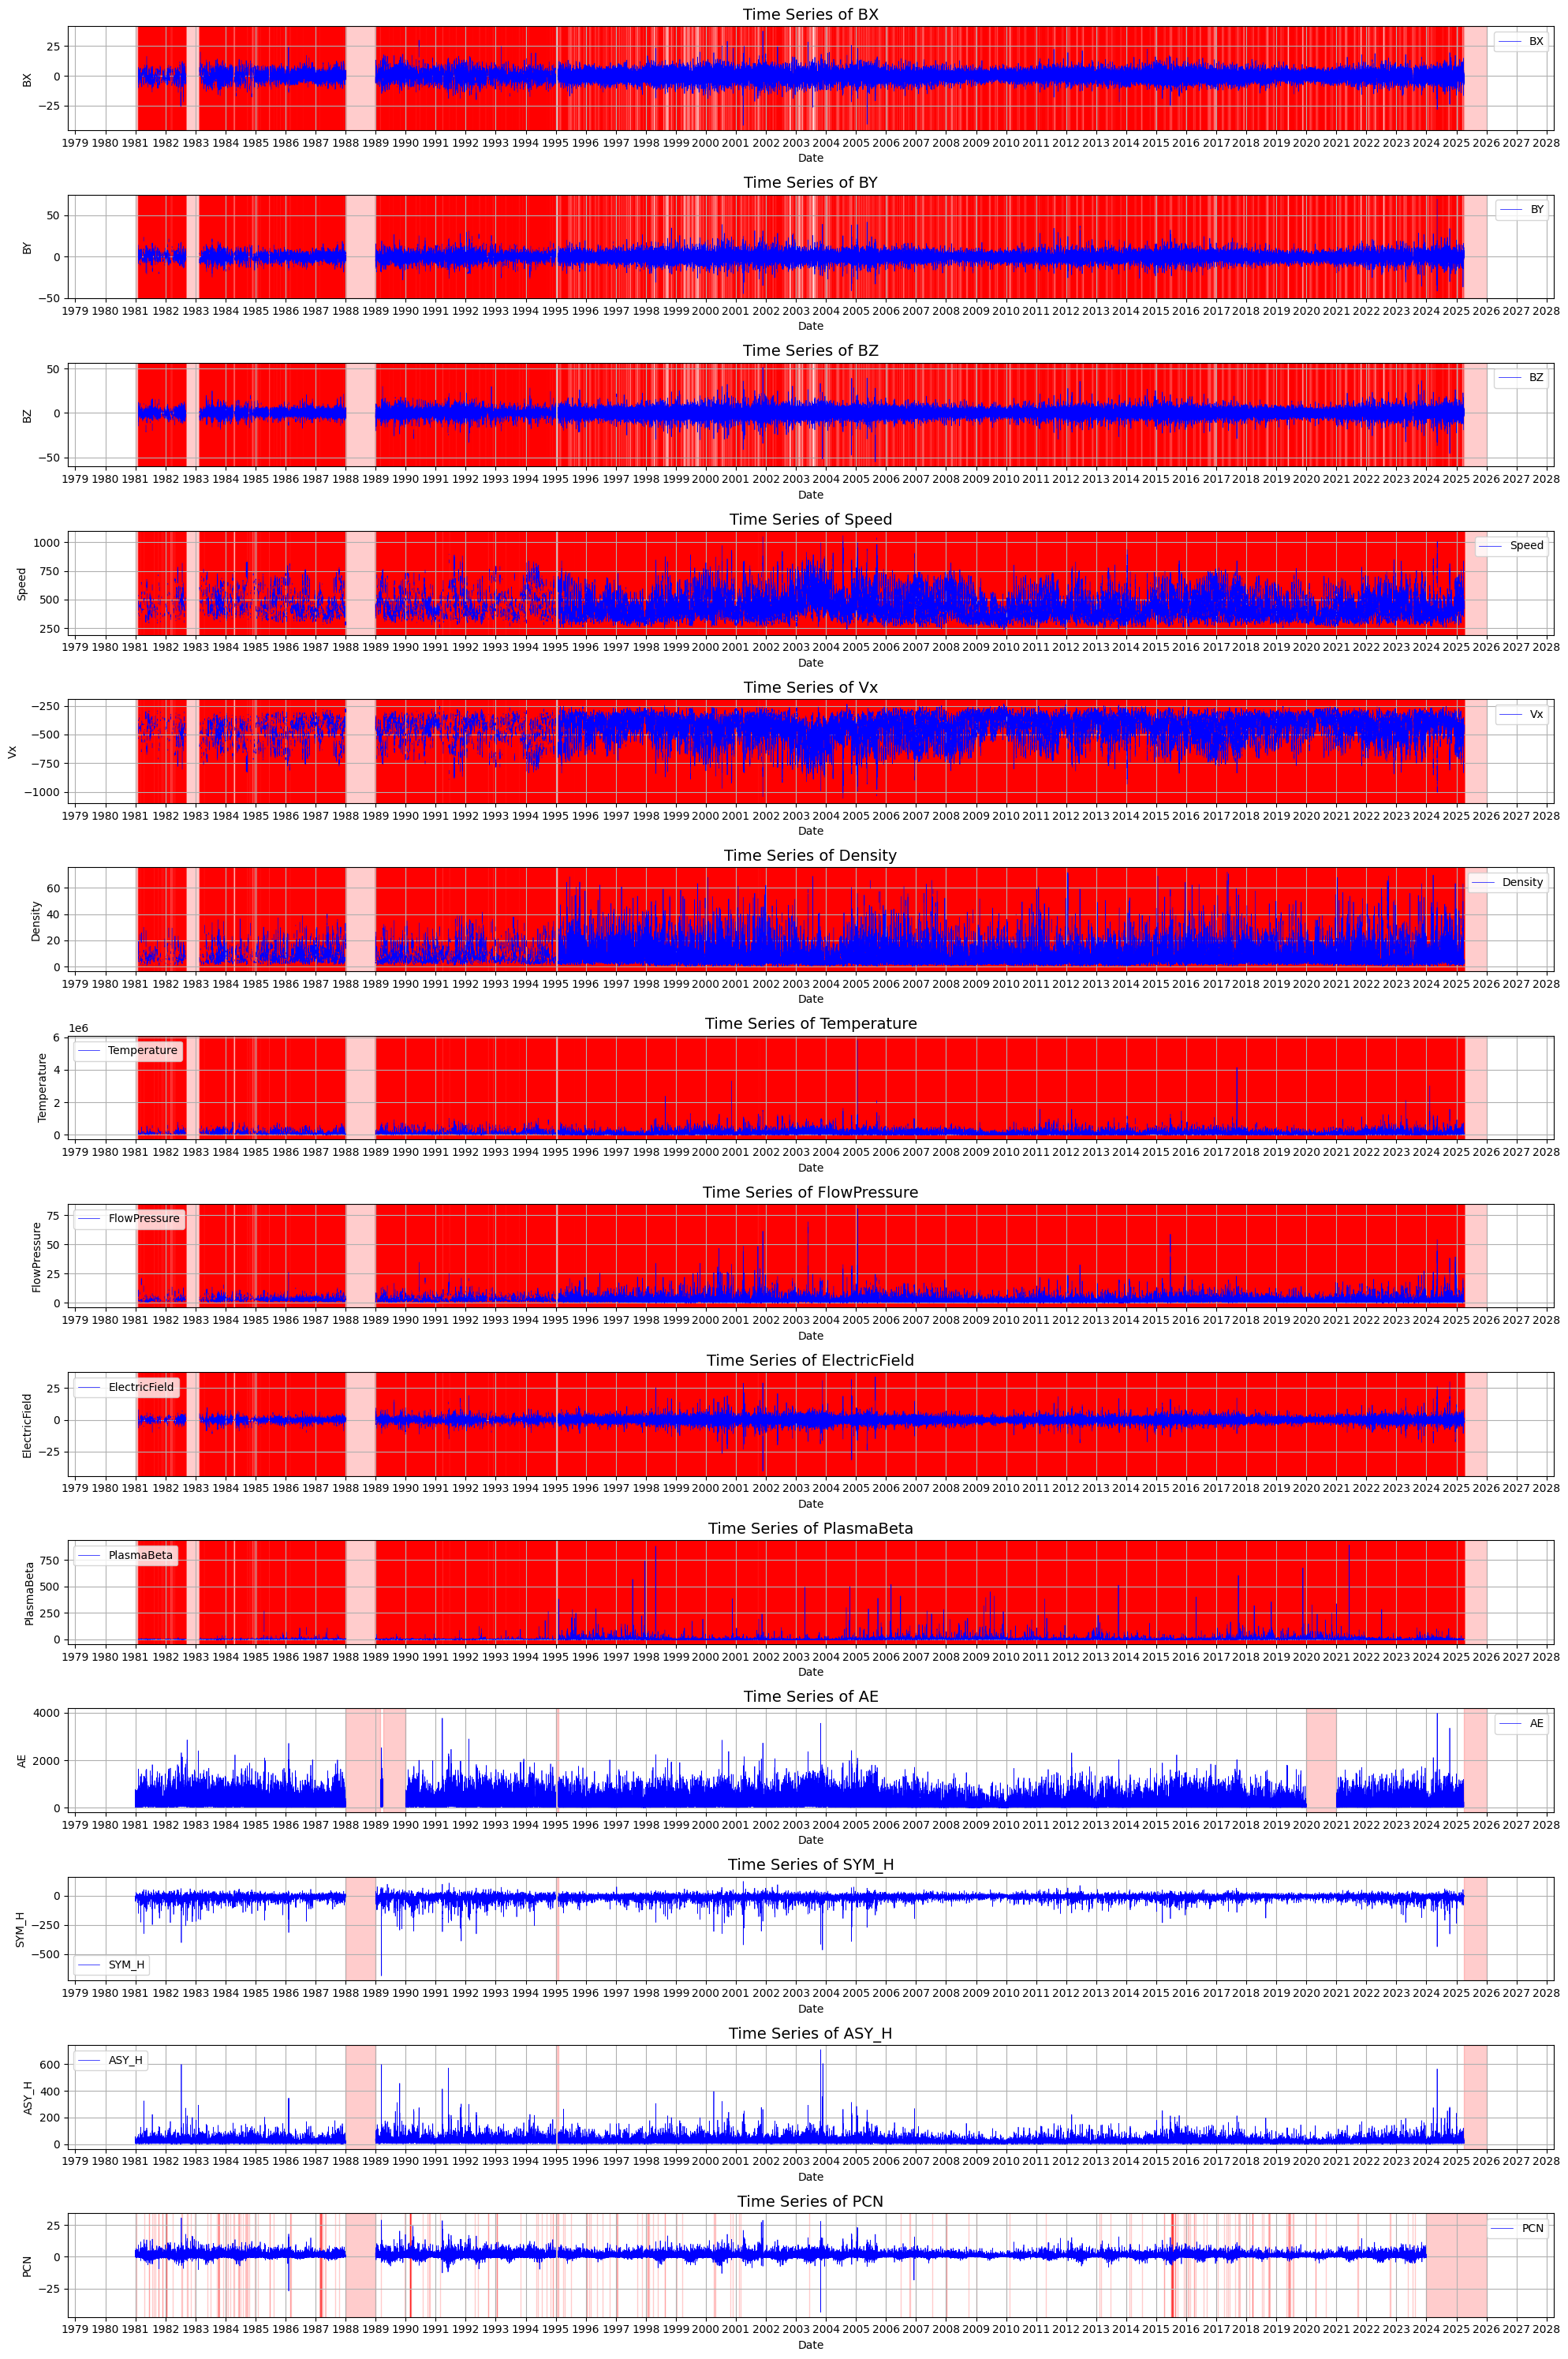

✅ Plot with gaps saved at: ../Output/Omni_Plots_and_Missing/omni_time_series_with_gaps.png


In [2]:
# ----------- Plot Time Series with Gaps ----------- #
plt.figure(figsize=(20, 30))

for i, var in enumerate(variables_to_plot, 1):
    ax = plt.subplot(len(variables_to_plot), 1, i)
    ax.plot(full_df.index, full_df[var], label=var, color='blue', linewidth=0.5)

    # Highlight NaN gaps
    na_mask = full_df[var].isna()
    if na_mask.any():
        group = (na_mask != na_mask.shift()).cumsum()
        for g in group[na_mask].unique():
            span = full_df.index[group == g]
            if len(span) > 0:
                ax.axvspan(span[0], span[-1], color='red', alpha=0.2)

    ax.set_title(f"Time Series of {var}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(var)
    ax.grid(True)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

plot_save_path = os.path.join(output_folder, "omni_time_series_with_gaps.png")
plt.savefig(plot_save_path, dpi=300)
plt.show()

print(f"✅ Plot with gaps saved at: {plot_save_path}")

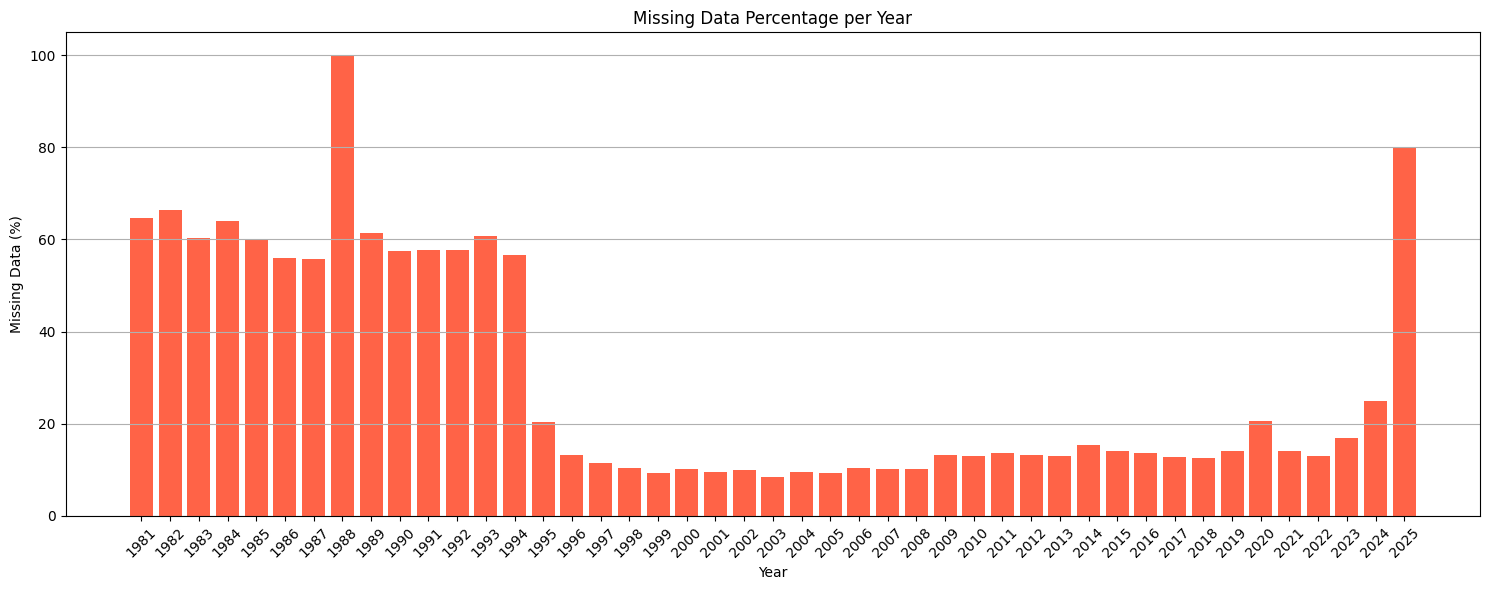

✅ Missing % per year plot saved at: ../Output/Omni_Plots_and_Missing/missing_percent_per_year.png


In [3]:
# ----------- Missing % Year Wise Plot ----------- #
missing_years = []

for year in range(start_year, end_year + 1):
    year_start = f"{year}-01-01"
    year_end = f"{year}-12-31 23:00"
    year_data = full_df.loc[year_start:year_end]

    total_points = year_data.shape[0] * len(variables_to_plot)
    missing_points = year_data.isna().sum().sum()

    missing_percent = (missing_points / total_points) * 100
    missing_years.append((year, missing_percent))

missing_years_df = pd.DataFrame(missing_years, columns=["Year", "Missing_Percent"])

# Plot missing percentage per year
plt.figure(figsize=(15, 6))
plt.bar(missing_years_df['Year'], missing_years_df['Missing_Percent'], color='tomato')
plt.xlabel('Year')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data Percentage per Year')
plt.grid(axis='y')
plt.xticks(missing_years_df['Year'], rotation=45)
plt.tight_layout()

missing_percent_plot = os.path.join(output_folder, "missing_percent_per_year.png")
plt.savefig(missing_percent_plot, dpi=300)
plt.show()

print(f"✅ Missing % per year plot saved at: {missing_percent_plot}")


## 3. Zoom Into Plot

In [2]:
# %%
%matplotlib widget

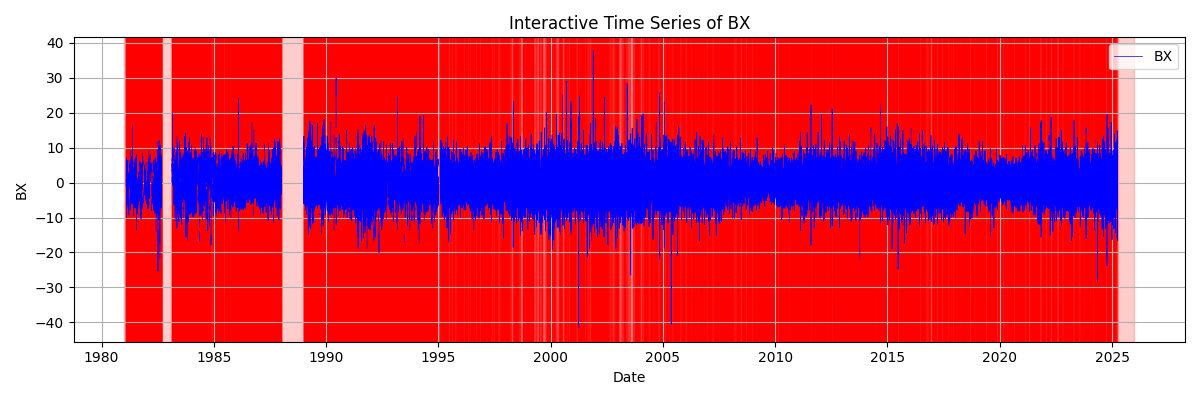

In [3]:
# %%
import matplotlib.pyplot as plt

# Choose variable to plot
variable = "BX"

# Create the interactive figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(full_df.index, full_df[variable], label=variable, linewidth=0.5, color='blue')

# Highlight NaNs
na_mask = full_df[variable].isna()
group = (na_mask != na_mask.shift()).cumsum()
for g in group[na_mask].unique():
    span = full_df.index[group == g]
    if len(span) > 0:
        ax.axvspan(span[0], span[-1], color='red', alpha=0.2)

# Labels and layout
ax.set_title(f"Interactive Time Series of {variable}")
ax.set_xlabel("Date")
ax.set_ylabel(variable)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


## 4. Export Interactive plots

In [6]:
import plotly.graph_objects as go
import os

# Folder to save interactive plots
output_dir = "../Output/interactive_plots/"
os.makedirs(output_dir, exist_ok=True)

for var in variables_to_plot:
    if var in full_df.columns:
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=full_df.index,
            y=full_df[var],
            mode='lines',
            name=var
        ))
        fig.update_layout(
            title=f'{var} over Time',
            xaxis_title='Time',
            yaxis_title=var,
            template='plotly_white'
        )
        fig.write_html(f"{output_dir}/{var}_plot.html")
    else:
        print(f"Variable '{var}' not found in dataframe.")


## 5. Correlation Matrix (Heatmap)

In [16]:
%matplotlib inline

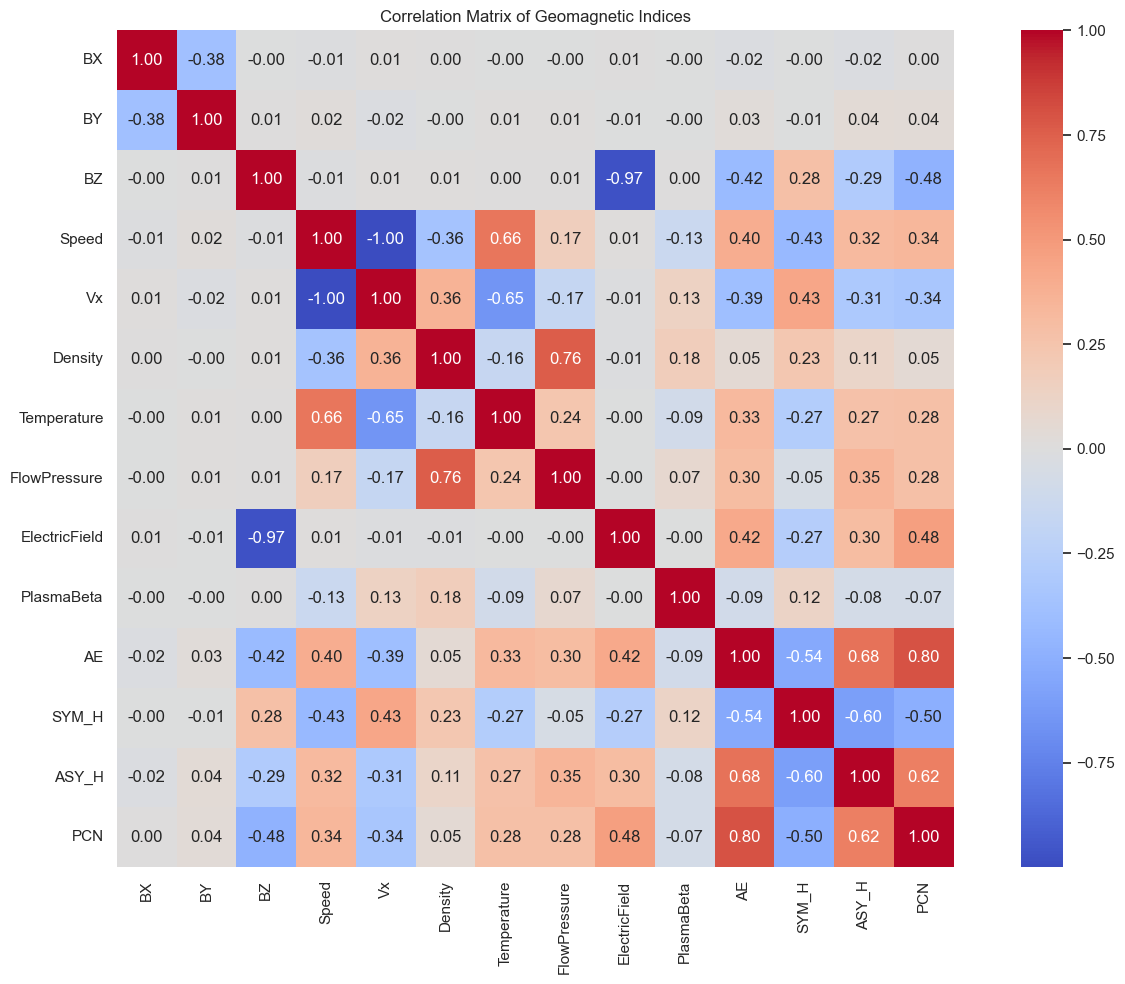

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Filter only numeric columns
numeric_df = full_df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Geomagnetic Indices")
plt.tight_layout()
plt.show()


## 6. Distribution Plots

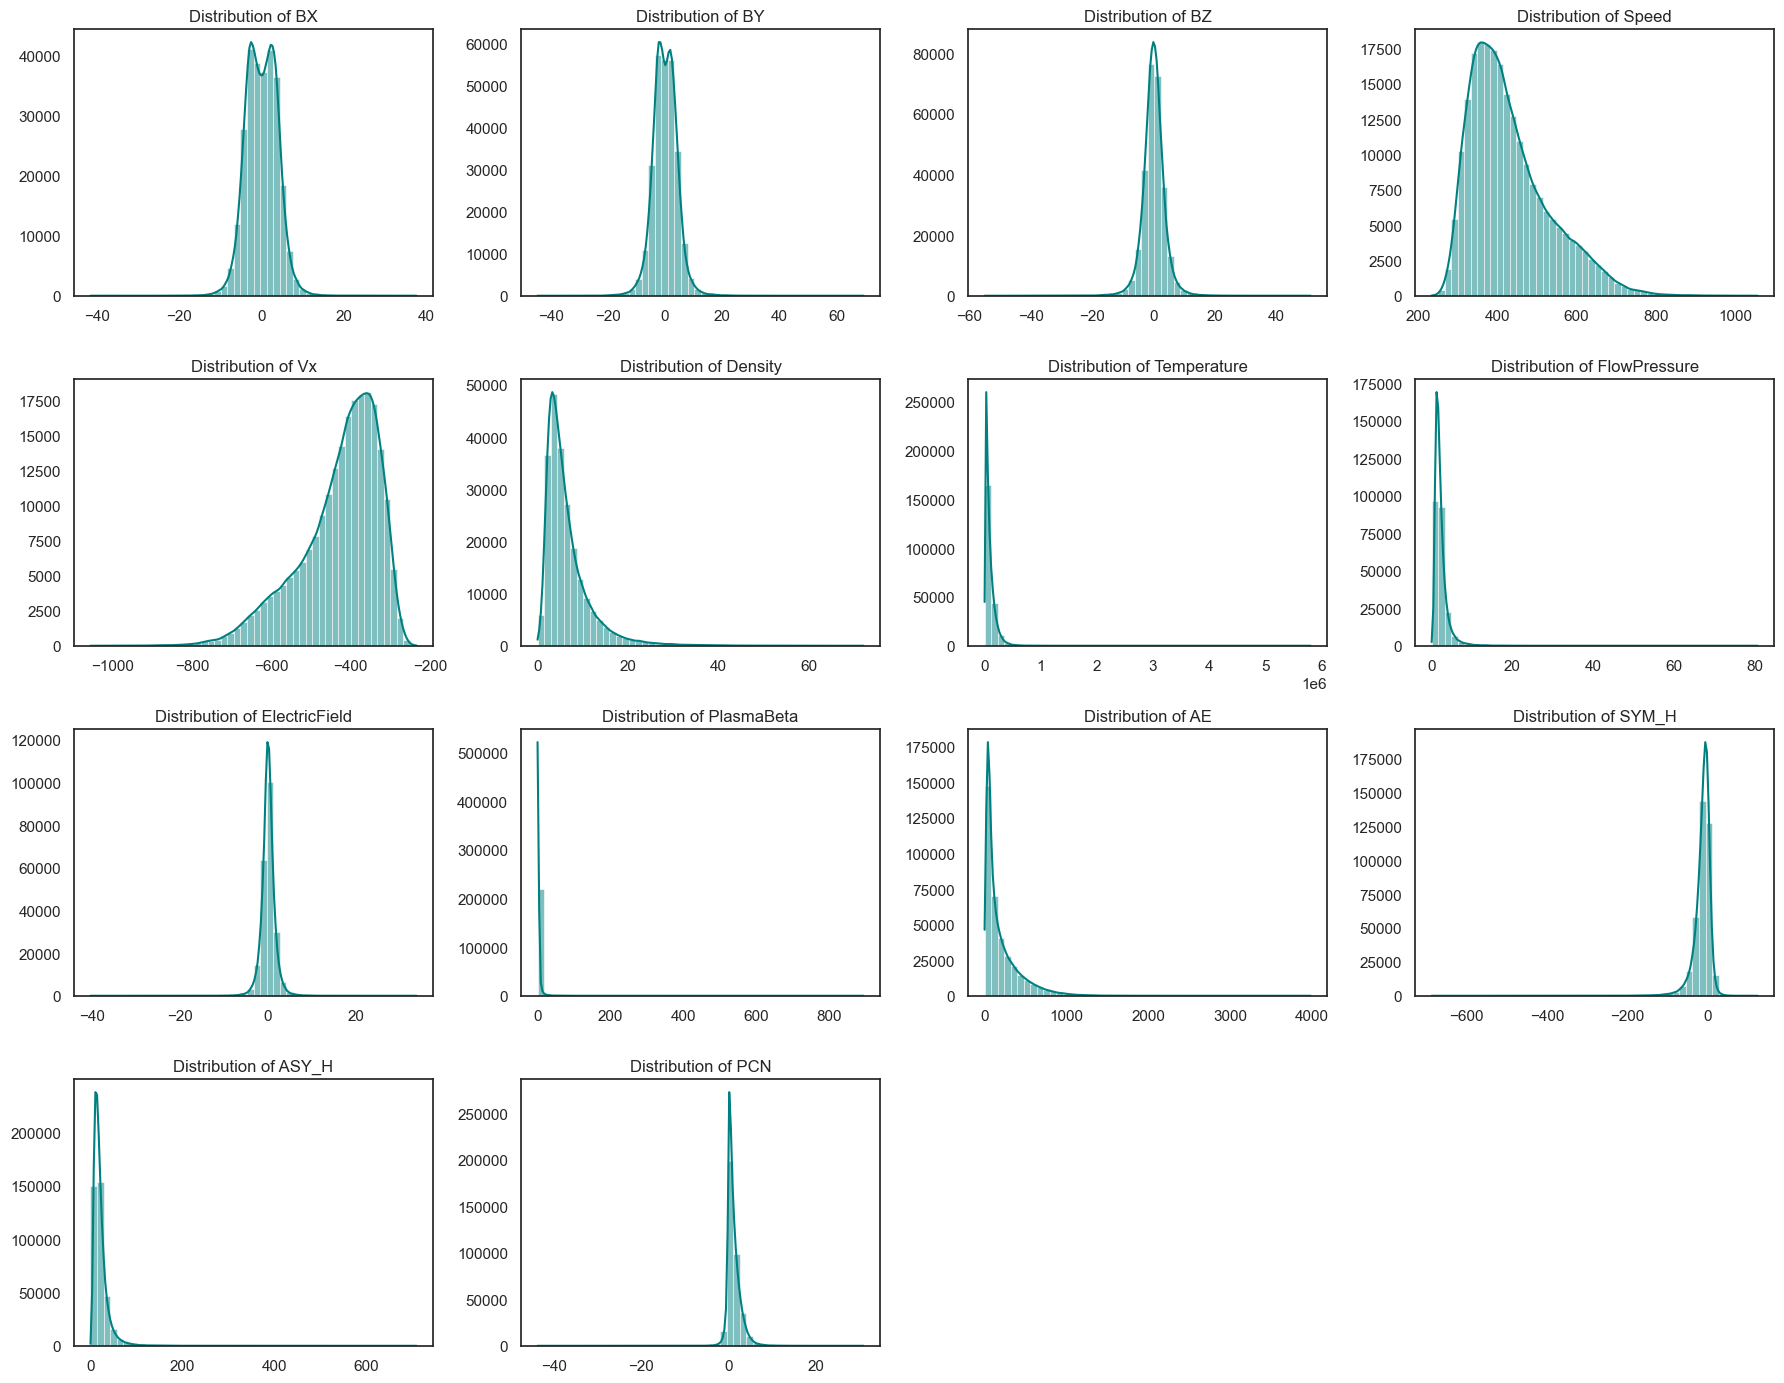

In [19]:
variables_to_plot = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# Plot histograms for each variable
import matplotlib.gridspec as gridspec

n = len(variables_to_plot)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(rows, cols)

for i, var in enumerate(variables_to_plot):
    ax = plt.subplot(gs[i])
    sns.histplot(full_df[var], bins=50, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {var}')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


## 7. Time Series Plot (Trends)

In [26]:
%matplotlib widget

In [ ]:
import plotly.graph_objects as go
import pandas as pd

fig = go.Figure()

# Add each variable as a trace
for var in variables_to_plot:
    fig.add_trace(go.Scatter(
        x=sample_df.index,
        y=sample_df[var],
        mode='lines',
        name=var
    ))

# Layout styling
fig.update_layout(
    title="Monthly Average Trends of Geomagnetic Parameters",
    xaxis_title="Date",
    yaxis_title="Value",
    legend_title="Parameters",
    template="plotly_white",
    width=1200,
    height=600
)

# Save as interactive HTML file
fig.write_html("../Output/interactive_plots/interactive_geomagnetic_plot.html")


## 8. Plot missing Values

In [23]:
%matplotlib inline

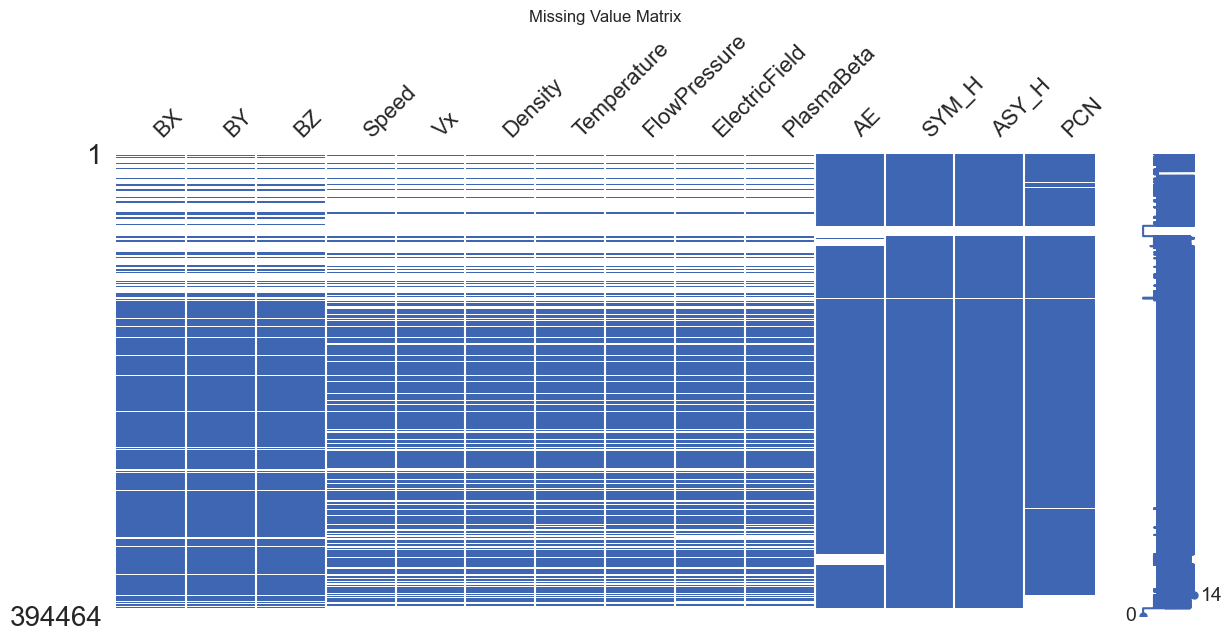

In [25]:
import missingno as msno

msno.matrix(full_df[variables_to_plot], figsize=(14, 6), color=(0.25, 0.4, 0.7))
plt.title("Missing Value Matrix")
plt.show()


## 9. Modeling

In [1]:
import os
import pandas as pd
from glob import glob

# Folder containing cleaned yearly CSVs
data_folder = "../Data/Omni_Cleaned_w8_NaN/"  # adjust path as needed

# Get all CSV file paths
csv_files = sorted(glob(os.path.join(data_folder, "omni_*.csv")))

# Read and concatenate all data
df_list = []

for file in csv_files:
    print(f"📄 Reading: {os.path.basename(file)}")
    df = pd.read_csv(file, parse_dates=['Datetime'], index_col='Datetime')
    
    # Drop duplicates
    df = df[~df.index.duplicated(keep='first')]

    # Ensure it's hourly indexed
    df = df.asfreq('H')
    
    df_list.append(df)

# Combine all years into one DataFrame
full_df = pd.concat(df_list)
print(f"\n✅ Combined shape: {full_df.shape}")
print(f"🕒 Date range: {full_df.index.min()} to {full_df.index.max()}")

# Optional: Preview
display(full_df.head())


📄 Reading: omni_1981.csv


C:\Users\hp\AppData\Local\Temp\ipykernel_12236\2425565596.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


📄 Reading: omni_1982.csv


C:\Users\hp\AppData\Local\Temp\ipykernel_12236\2425565596.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


📄 Reading: omni_1983.csv


...

📄 Reading: omni_2024.csv


C:\Users\hp\AppData\Local\Temp\ipykernel_12236\2425565596.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


📄 Reading: omni_2025.csv

✅ Combined shape: (390792, 27)
🕒 Date range: 1981-01-01 00:00:00 to 2025-03-31 23:00:00


C:\Users\hp\AppData\Local\Temp\ipykernel_12236\2425565596.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


,Year,Day,Hour,Minute,IMF_ID,SW_ID,TimeShift,BX,BY,BZ,...,Xgse,Ygse,Zgse,BSN_X,BSN_Y,BSN_Z,AE,SYM_H,ASY_H,PCN
Datetime,,,,,,,,,,,,,,,,,,,,,
1981-01-01 00:00:00,1981,1,0,0,99,99,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,57.0,-31,35,NaN
1981-01-01 01:00:00,1981,1,1,0,99,99,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,27.0,-30,36,-0.10
1981-01-01 02:00:00,1981,1,2,0,99,99,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,35.0,-28,34,-0.03
1981-01-01 03:00:00,1981,1,3,0,99,99,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,115.0,-32,32,1.03
1981-01-01 04:00:00,1981,1,4,0,99,99,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,278.0,-35,29,2.62


In [2]:
# Define input features (X) and targets (Y)
solar_wind_features = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta"
]

earth_targets = ["AE", "SYM_H", "ASY_H", "PCN"]

# Drop rows where any target is missing
df_model = full_df[solar_wind_features + earth_targets].dropna()

# Split into features and targets
X = df_model[solar_wind_features]
Y = df_model[earth_targets]

print("✅ Shape of input X:", X.shape)
print("✅ Shape of target Y:", Y.shape)


✅ Shape of input X: (209638, 10)
✅ Shape of target Y: (209638, 4)


### 9.1. Scale Input and Output

In [3]:
from sklearn.preprocessing import MinMaxScaler

input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

X_scaled = input_scaler.fit_transform(X)
Y_scaled = output_scaler.fit_transform(Y)


###  9.2. Create Sequences for LSTM (e.g., 24-hour input window)

In [4]:
import numpy as np

def create_sequences(X, Y, window_size=24):
    X_seq, Y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        Y_seq.append(Y[i+window_size])  # Predict the next time step's target
    return np.array(X_seq), np.array(Y_seq)

window_size = 24
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, window_size)

print("📐 X_seq shape:", X_seq.shape)  # (samples, timesteps, features)
print("🎯 Y_seq shape:", Y_seq.shape)  # (samples, target_dims)


📐 X_seq shape: (209614, 24, 10)
🎯 Y_seq shape: (209614, 4)


### 9.3. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, Y_seq, test_size=0.2, shuffle=False  # no shuffle to preserve time order
)


### 9.4. Build the LSTM Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(window_size, X.shape[1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(Y.shape[1])  # Output layer for AE, SYM_H, ASY_H, PCN
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\hp\Downloads\Space_Weather_Event_Analysis\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,412 (83.64 KB)

 Trainable params: 21,412 (83.64 KB)

 Non-trainable params: 0 (0.00 B)

### 9.5. Train the Model

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0079 - val_loss: 8.5451e-04
Epoch 2/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0011 - val_loss: 7.9733e-04
Epoch 3/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0010 - val_loss: 8.0969e-04
Epoch 4/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0010 - val_loss: 7.6532e-04
Epoch 5/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.7816e-04 - val_loss: 7.5563e-04
Epoch 6/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.6733e-04 - val_loss: 7.4765e-04
Epoch 7/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.6450e-04 - val_loss: 7.3861e-04
Epoch 8/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.6393e-04 - val_loss: 7.5379e-04
Epoch 9/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.5495e-04 - val_loss: 7.3775e-04
Epoch 10/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 9.5499e-04 - val_loss: 7.6926e-04
Epoch 11/20
2621/2621 ━━━━━━━━━━━━━━━━━━━━ 20

In [9]:
# Save the full model (architecture + weights)
model.save("../Models/earth_param_lstm_model.h5")
print("✅ Model saved as earth_param_lstm_model.h5")


✅ Model saved as earth_param_lstm_model.h5


### 9.6. Visualize Predictions vs Ground Truth for All Earth Parameters

1311/1311 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


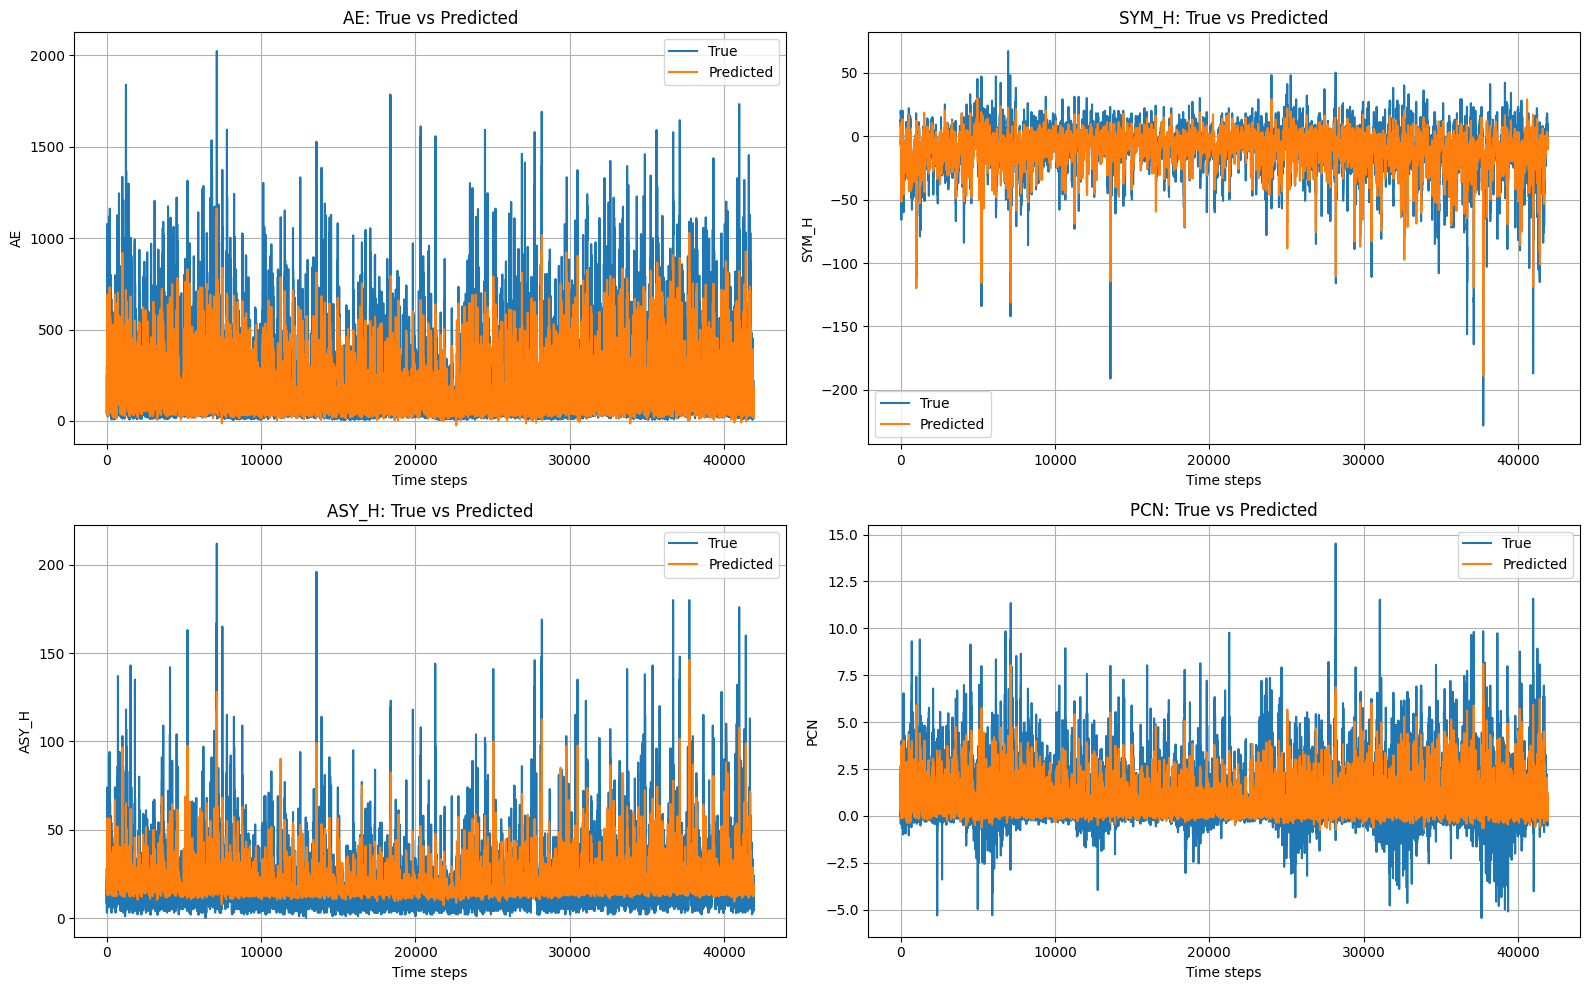

In [11]:
import matplotlib.pyplot as plt

# Predict
y_pred_scaled = model.predict(X_test)
y_pred = output_scaler.inverse_transform(y_pred_scaled)
y_true = output_scaler.inverse_transform(y_test)

# Plot all targets
plt.figure(figsize=(16, 10))
for i, name in enumerate(earth_targets):
    plt.subplot(2, 2, i+1)
    plt.plot(y_true[:, i], label="True")
    plt.plot(y_pred[:, i], label="Predicted")
    plt.title(f"{name}: True vs Predicted")
    plt.xlabel("Time steps")
    plt.ylabel(name)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### 9.7. Calculate and Show Error Metrics

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

earth_targets = ["AE", "SYM_H", "ASY_H", "PCN"]

print("📊 Error Metrics:\n")
for i, name in enumerate(earth_targets):
    mse = mean_squared_error(y_true[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    print(f"{name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")


📊 Error Metrics:

AE: MAE = 81.10, RMSE = 131.57
SYM_H: MAE = 6.70, RMSE = 9.20
ASY_H: MAE = 6.95, RMSE = 10.01
PCN: MAE = 0.64, RMSE = 0.93


### Save Biases

In [14]:
import joblib

joblib.dump(input_scaler, "../Models/input_scaler.pkl")
joblib.dump(output_scaler, "../Models/output_scaler.pkl")
print("✅ Scalers saved: input_scaler.pkl, output_scaler.pkl")


✅ Scalers saved: input_scaler.pkl, output_scaler.pkl


In [15]:
import numpy as np

# Dictionary to store biases
bias_dict = {}

# Loop through layers
for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) >= 2:  # [weights, biases] at least
        bias = weights[1]  # biases are always the second element
        bias_dict[layer.name] = bias


In [16]:
## save as json
import json

# Convert all numpy arrays to lists for JSON serialization
bias_dict_serializable = {k: v.tolist() for k, v in bias_dict.items()}

with open("../Models/lstm_model_biases.json", "w") as f:
    json.dump(bias_dict_serializable, f, indent=2)

print("✅ Biases saved as lstm_model_biases.json")


✅ Biases saved as lstm_model_biases.json


In [17]:
## save as npz
np.savez("../Models/lstm_model_biases.npz", **bias_dict)
print("✅ Biases saved as lstm_model_biases.npz")


✅ Biases saved as lstm_model_biases.npz
